# Splines de Suavizamiento

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from pygam import LinearGAM,  s

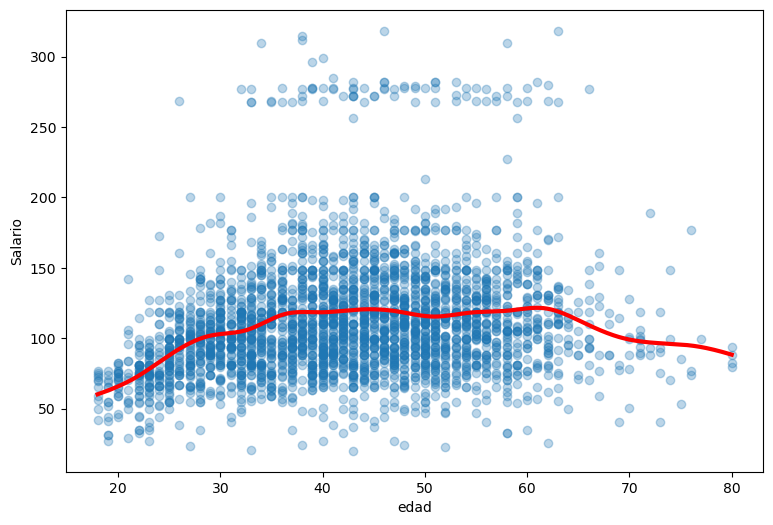

In [2]:
#Defino variables
Wage = load_data("Wage")
age = Wage['age']
y = Wage['wage']
#Reshape
X_age = np.asarray(age).reshape(-1,1)
#Definimos modelos
gam = LinearGAM(s(0, lam = 0.6))
#Ajustamos
gam.fit(X_age,y)

age_grid = np.linspace(age.min(),age.max(),500)
age_grid_matrix = age_grid.reshape(-1,1)

pred = gam.predict(age_grid_matrix)

#Plot
plt.figure(figsize=(9,6))
plt.scatter(age, y, alpha = 0.3)
plt.plot(age_grid, pred, linewidth = 3, color = "red")

plt.xlabel("edad")
plt.ylabel("Salario")
plt.show()

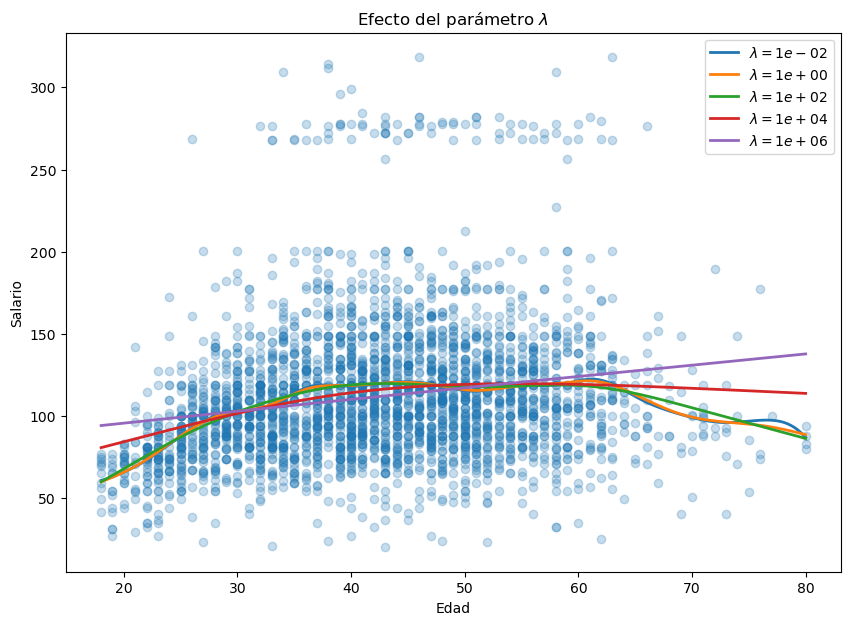

In [3]:
# Comparación con lambdas
lambdas = np.logspace(-2,6,5)
plt.figure(figsize = (10,7))
plt.scatter(
    age,
    y,
    alpha = 0.25
)

for lam in lambdas:
    gam_lam = LinearGAM(
        s(0, lam = lam)
    )

    gam_lam.fit(X_age, y)

    pred_lam = gam_lam.predict(age_grid_matrix)

    plt.plot(
        age_grid,
        pred_lam,
        linewidth = 2,
        label = fr"$\lambda = {lam:.0e}$"
    
    )

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title(r"Efecto del parámetro $\lambda$")
plt.legend()
plt.show()
    

In [4]:
lam_grid = np.logspace(-3,5,30)

gam_opt = LinearGAM(
    s(0)
)

gam_opt.gridsearch(
    X_age,
    y,
    lam = lam_grid,
    progress = False
)
gam_opt.lam

[[np.float64(174.33288221999874)]]

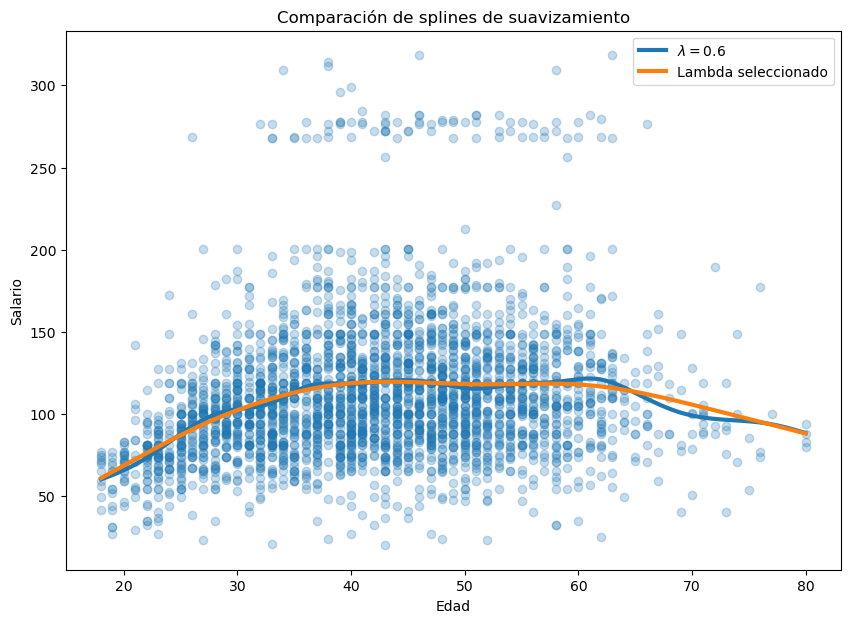

In [5]:
pred_default = gam.predict(age_grid_matrix)
pred_opt = gam_opt.predict(age_grid_matrix)

plt.figure(figsize = (10,7))
plt.scatter(
    age,
    y,
    alpha = 0.25
)

plt.plot(
    age_grid,
    pred_default,
    linewidth = 3,
    label = r"$\lambda = 0.6$"
)

plt.plot(age_grid,
        pred_opt,
        linewidth = 3,
         label = r"Lambda seleccionado"
        )
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Comparación de splines de suavizamiento')
plt.legend()
plt.show()


In [6]:
#Grados de libertad del modelo seleccionado
gam_opt.statistics_["edof"]

np.float64(6.061955860252569)

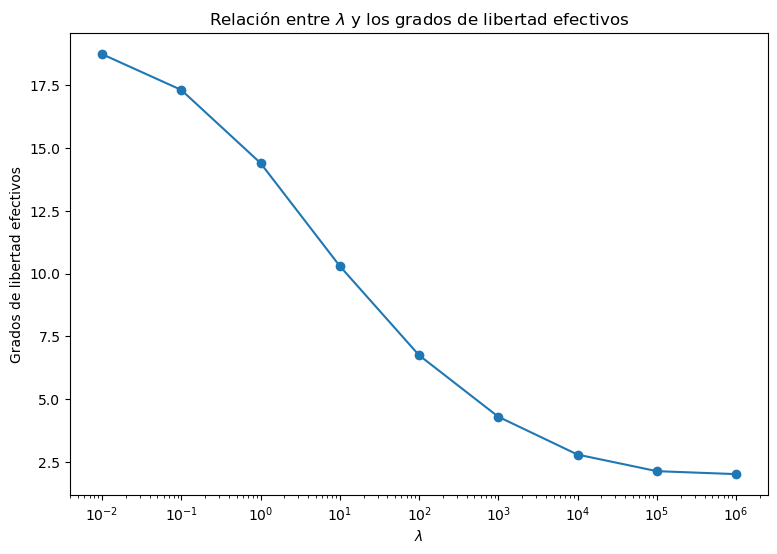

In [7]:
resultados = []
for lam in np.logspace(-2, 6, 9):
    modelo = LinearGAM(
        s(0,lam = lam)
    ).fit(X_age,y)

    resultados.append({
        "lambda": lam,
        "df_efectivos": modelo.statistics_["edof"]
    })

df_lambda = pd.DataFrame(resultados)

plt.figure(figsize = (9,6))

plt.plot(
    df_lambda["lambda"],
    df_lambda["df_efectivos"],
    marker = "o"
)

plt.xscale("log")

plt.xlabel(r"$\lambda$")
plt.ylabel("Grados de libertad efectivos")
plt.title(r"Relación entre $\lambda$ y los grados de libertad efectivos")

plt.show()


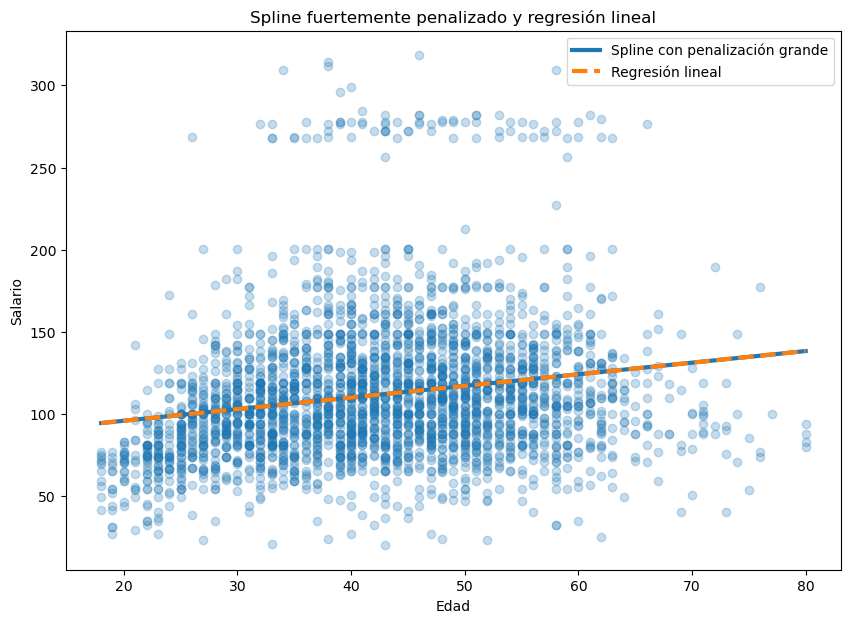

In [8]:
#Comparacion con regresion lineal
coef_lineal = np.polyfit(
    age,
    y,
    deg= 1
)

pred_lineal = np.polyval(
    coef_lineal,
    age_grid
)

#ajustamos un spline on una penalización muy grande
gam_suave = LinearGAM(s(0, lam = 1e10))

gam_suave.fit(X_age, y)

pred_suave = gam_suave.predict(
    age_grid_matrix
)

plt.figure(figsize=(10, 7))

plt.scatter(
    age,
    y,
    alpha=0.25
)

plt.plot(
    age_grid,
    pred_suave,
    linewidth=3,
    label="Spline con penalización grande"
)

plt.plot(
    age_grid,
    pred_lineal,
    linestyle="--",
    linewidth=3,
    label="Regresión lineal"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline fuertemente penalizado y regresión lineal")
plt.legend()

plt.show()

## EJERCICIOS

### 5.17.1 Ejercicio 1. Efecto de 
Ajusta splines de suavizamiento utilizando los siguientes valores:


Representa todos los ajustes en una misma gráfica.

Preguntas:

¿Qué ocurre con la curva conforme aumenta?

RESPUESTA: Se parece cada vez mas a una función lineal

¿Cuál de los modelos parece más flexible?

RESPUESTA:El de lambda igual a 10e-3

¿Cuál parece presentar mayor sesgo?

RESPUESTA: Parece ser que el  modelo mas flexible presenta mayor sesgo

¿Cuál podría presentar mayor varianza?

RESPUESTA: el de modelo casi lineal, parece variar bastante las predicciones a los valores reales

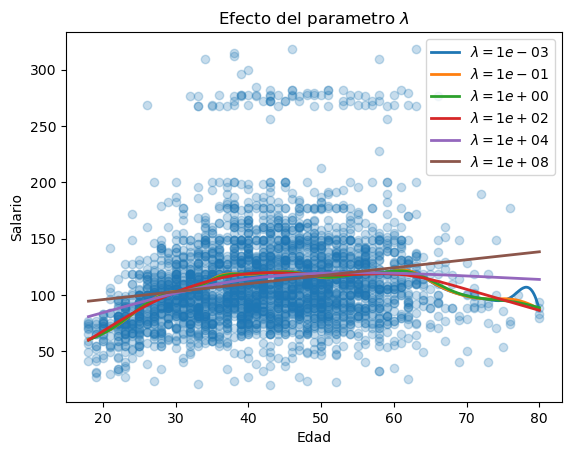

In [9]:
lambdas = [10e-4,10e-2,1,10**2,10**4,10**8]
plt.figure()
plt.scatter(age,y, alpha = 0.25)
for lam in lambdas:
    gam_lam = LinearGAM(
        s(0,lam = lam)
    )
    gam_lam.fit(X_age, y)
    pred_lam = gam_lam.predict(age_grid_matrix)

    plt.plot(
        age_grid,
        pred_lam,
        linewidth = 2,
        label = fr"$\lambda = {lam:.0e}$"
        
    )
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title(r"Efecto del parametro $\lambda$")
plt.legend()
plt.show()

## 5.17.2 Ejercicio 2. Grados de libertad efectivos
Para cada uno de los valores de 
 del ejercicio anterior, obtén los grados de libertad efectivos mediante

modelo.statistics_["edof"]

Construye una tabla con las columnas:

Grados de libertad efectivos
Después representa gráficamente


Utiliza escala logarítmica para el eje correspondiente a 
.

Pregunta: ¿los resultados coinciden con la relación teórica esperada?

RESPUESTA: Si a mayor restricción en el modelo menor es la cantidad de grados de libertad efectivos

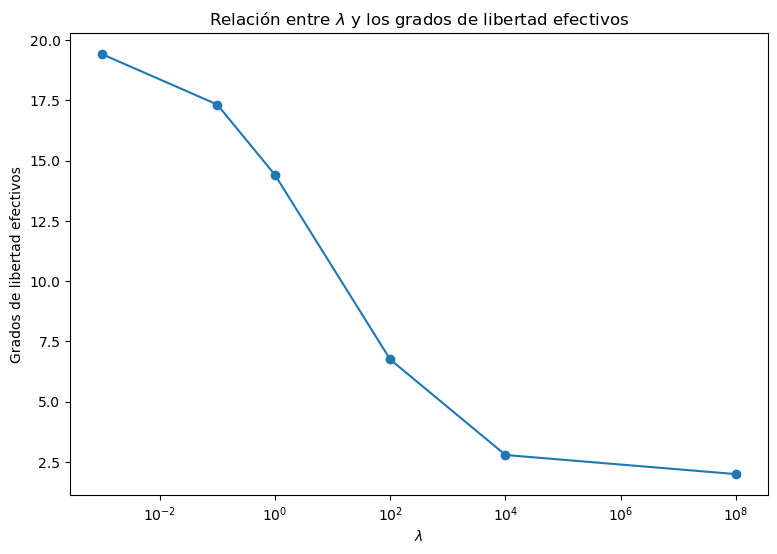

In [10]:
resultados = []
for lam in lambdas:
    modelo = LinearGAM(
        s(0,lam = lam)
    ).fit(X_age,y)

    resultados.append({
        "lambda": lam,
        "df_efectivos": modelo.statistics_["edof"]
    })

df_lambda = pd.DataFrame(resultados)

plt.figure(figsize = (9,6))

plt.plot(
    df_lambda["lambda"],
    df_lambda["df_efectivos"],
    marker = "o"
)

plt.xscale("log")

plt.xlabel(r"$\lambda$")
plt.ylabel("Grados de libertad efectivos")
plt.title(r"Relación entre $\lambda$ y los grados de libertad efectivos")

plt.show()

### 5.17.3 Ejercicio 3. Selección de 
Utiliza gridsearch() para seleccionar automáticamente un valor de 
.

Considera como candidatos


Después:

reporta el valor seleccionado;

reporta sus grados de libertad efectivos;

grafica el spline resultante;

compáralo con los ajustes obtenidos manualmente.

RESPUESTA: parece ser uno de los modelos mas flexibles de los hechos anteriormente

Pregunta: ¿el procedimiento seleccionó un modelo relativamente flexible o relativamente suave?

RESPUESTA: Selecciono un modelo relativamente flexibles.

Justifica tu respuesta utilizando tanto la gráfica como los grados de libertad efectivos.

In [11]:
lambdas = np.logspace(-4,6,10)
gam_opt = LinearGAM(
    s(0)
)

gam_opt.gridsearch(
    X_age,
    y,
    lam = lambdas,
    progress = False
)
print("lambda: ", gam_opt.lam)
print("Grados de libertad efectivos: ",gam_opt.statistics_["edof"])

lambda:  [[np.float64(464.1588833612782)]]
Grados de libertad efectivos:  5.001888857413391


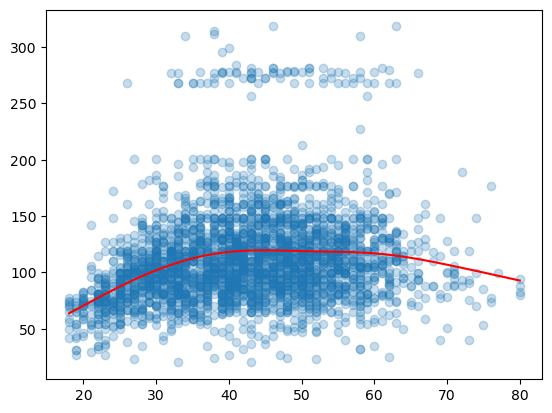

In [12]:
pred = gam_opt.predict(age_grid_matrix)
plt.figure()
plt.scatter(age,y,alpha = 0.25)
plt.plot(age_grid, pred, color = 'red')
plt.show()

### Ejercicio 4
Ajusta splines utilizando valores cada vez mayores de 
.



Ajusta también una regresión lineal de wage sobre age.

Representa todos los modelos.

Pregunta: ¿qué observas conforme 
 aumenta? Explica el resultado utilizando la penalización

Esto crea una regresión lineal, esto pasa debido a que conforme el parametro lambda aumenta la flexibilidad disminuye.

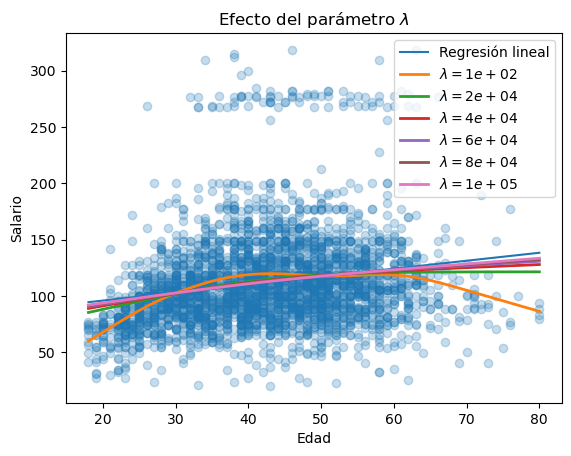

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from pygam import LinearGAM, s

# Valores de lambda
lambdas = np.linspace(100, 100_000, 6)


age_grid = np.linspace(
    age.to_numpy().min(),
    age.to_numpy().max(),
    500
)


age_grid_matrix = age_grid.reshape(-1, 1)


model = LinearRegression()

model.fit(
    age.to_numpy().reshape(-1, 1),
    y.to_numpy()
)



plt.figure()

# Datos originales
plt.scatter(
    age,
    y,
    alpha=0.25
)

# Regresión lineal
plt.plot(
    age_grid,
    model.predict(age_grid_matrix),
    label="Regresión lineal"
)



for lam in lambdas:

    gam_lam = LinearGAM(
        s(0, lam=lam)
    )

    gam_lam.fit(
        X_age,
        y
    )

    pred_lam = gam_lam.predict(
        age_grid_matrix
    )

    plt.plot(
        age_grid,
        pred_lam,
        linewidth=2,
        label=fr"$\lambda = {lam:.0e}$"
    )



plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title(r"Efecto del parámetro $\lambda$")
plt.legend()
plt.show()

### 5.17.5 Ejercicio 5. Interpretación
Sin ejecutar código, responde:

Si un spline tiene muchos grados de libertad efectivos, ¿esperas que 
 sea grande o pequeño?

RESPUESTA: espero que lambda sea pequeño ya que tiene poca penalización

 ¿qué tipo de función esperamos obtener?
 
 RESPUESTA: Se espera una función lineal

¿Por qué no es conveniente seleccionar 
 únicamente observando qué modelo tiene el menor error de entrenamiento?

RESPUESTA: Porque podria ser propenso al error de prueba 

¿Cuál es la diferencia conceptual entre el número de parámetros del spline y sus grados de libertad efectivos?

RESPUESTA: que los grados de libertad son una relacion entre el numero de parametros y ademas la cantidad de nodos en los que se dividen los datos

¿Qué relación existe entre 
, flexibilidad, sesgo y varianza?

RESPUESTA: La relacion es que la flexibilidad produce menos sesgo y mas varianza.

### 5.17.6 Ejercicio 6. Otro predictor
Repite el análisis utilizando year como predictor y wage como variable respuesta.

Construye un spline de suavizamiento.

Explora distintos valores de .

Obtén el valor seleccionado mediante gridsearch().

Obtén los grados de libertad efectivos.

Compara la relación year–wage con la relación age–wage.

Pregunta: ¿parece necesaria la misma cantidad de flexibilidad para modelar ambas relaciones? Justifica tu respuesta.

No, de hecho todos los splines parecen ser bastante similares

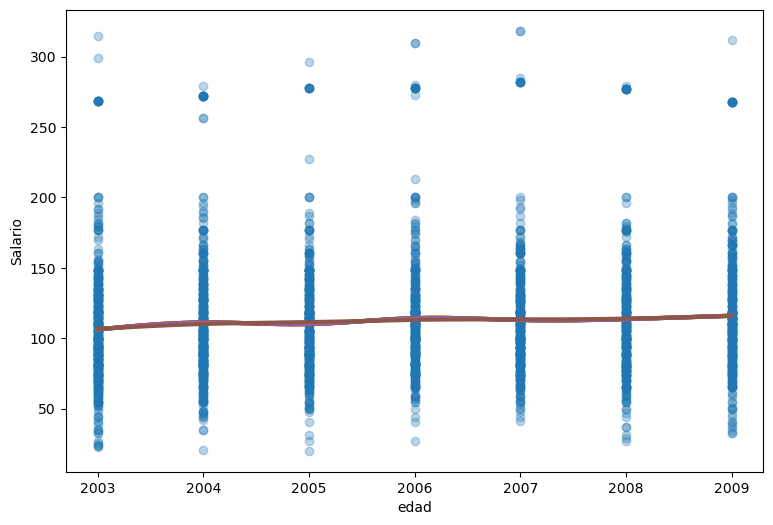

In [14]:
#Defino variables
Wage = load_data("Wage")
age = Wage['year']
y = Wage['wage']
#Reshape
X_age = np.asarray(age).reshape(-1,1)

lambdas = np.logspace(-3,3,6)
#Plot
plt.figure(figsize=(9,6))
plt.scatter(age, y, alpha = 0.3)
#Definimos modelos
for lam in lambdas:
    gam = LinearGAM(s(0, lam = lam))
    #Ajustamos
    gam.fit(X_age,y)
    
    age_grid = np.linspace(age.min(),age.max(),500)
    age_grid_matrix = age_grid.reshape(-1,1)
    
    pred = gam.predict(age_grid_matrix)
    
    
    plt.plot(age_grid, pred, linewidth = 3)

plt.xlabel("edad")
plt.ylabel("Salario")
plt.show()

In [15]:
lambdas = np.linspace(10e-4,10**6)
gam_opt = LinearGAM(
    s(0)
)

gam_opt.gridsearch(
    X_age,
    y,
    lam = lambdas,
    progress = False
)
print("lambda: ", gam_opt.lam)
print("Grados de libertad efectivos: ",gam_opt.statistics_["edof"])

lambda:  [[np.float64(1000000.0)]]
Grados de libertad efectivos:  2.048992505125555


### 5.17.7 Ejercicio 7. Reflexión
Supongamos que dos splines producen prácticamente el mismo desempeño predictivo:

Modelo A: 15 grados de libertad
;
Modelo B: 5 grados de libertad
.
¿Cuál preferirías?

RESPUESTA: Preferiria el modelo de 5 grados de libertad, ya que es menos complejo, mas interpretable y tiene menos riesgo de sobreajuste

Explica tu respuesta considerando:

complejidad;
interpretabilidad;
riesgo de sobreajuste.